### ***Using neural networks on MNIST Data*** 

#### ***Import Necessary Libraries***

In [1]:
import pandas as pd
import numpy as np
import keras

from tensorflow.keras.utils import to_categorical # used to convert integer class labels into one-hot encoded vectors

from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

# ModelCheckpoint: to save the model after every epoch
# ReduceLROnPlateau: to reduce the learning rate when a metric has stopped improving

import warnings
warnings.filterwarnings('ignore')

#### ***Reading the data***

In [2]:
from keras.datasets import mnist # keras is now integrated into tensorflow
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [3]:
print(x_train.shape) # x_train is a 3-dimensional array, it typically represents: (number of samples, height, width)
print(x_test.shape)  
print(y_train.shape) # y_train is a 1-dimensional array, it typically represents: (number of samples,)
print(y_test.shape)  

(60000, 28, 28)
(10000, 28, 28)
(60000,)
(10000,)


***Training Dataset has 60K images of `numbers` with resolution 28 x 28 and 60K labels indicating the actual number***

In [4]:
print(f'First few numbers in the training dataset: {y_train[:10]}')
print(f'First few numbers in the testing dataset: {y_test[:10]}')

First few numbers in the training dataset: [5 0 4 1 9 2 1 3 1 4]
First few numbers in the testing dataset: [7 2 1 0 4 1 4 9 5 9]


#### ***Visualizing images from our data***

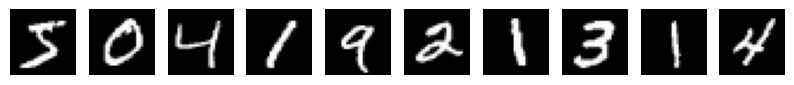

label for each of the above image: [5 0 4 1 9 2 1 3 1 4]


In [5]:
# visualizing the first 10 images in the dataset and their labels


# y_train is a 1-dimensional array, it typically represents: (number of samples,)

%matplotlib inline
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 1))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.axis('off')
plt.show()
print('label for each of the above image: %s' % (y_train[0:10]))

#### ***Normalizing our train and test data***

In [6]:
# Flatten the images
image_vector_size = 28*28
x_train = x_train.reshape(x_train.shape[0], image_vector_size) # this reshapes the x_train from (60000, 28, 28) to (60000, 784)
x_test = x_test.reshape(x_test.shape[0], image_vector_size) # this reshapes the x_test from (10000, 28, 28) to (10000, 784)

# # normalize inputs from 0-255 to 0-1
x_train = x_train / 255.0
x_test = x_test / 255.0

print('Training set', x_train.shape, y_train.shape)
print('Test set', x_test.shape, y_test.shape)

Training set (60000, 784) (60000,)
Test set (10000, 784) (10000,)


#### ***One Hot Encoding the target variables***

In [7]:
# Convert to "one-hot" vectors using the to_categorical function
num_classes = 10
y_train = to_categorical(y_train, num_classes)
y_test_cat=to_categorical(y_test,num_classes)

In [8]:
print("First 5 training lables as one-hot encoded vectors:\n", y_train[:5])

First 5 training lables as one-hot encoded vectors:
 [[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


#### ***Definfing the sequential Model***

In [9]:
# define model

from tensorflow.keras import losses
from tensorflow.keras import optimizers
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

image_size=28*28

# create model
model = Sequential()  

model.add(Dense(256, activation='relu',kernel_initializer='he_uniform',input_shape=(image_size,))) # input data is tuple of 1d array of 784 (28*28)
model.add(Dense(64, activation='relu',kernel_initializer='he_uniform'))
model.add(Dense(64, activation='relu',kernel_initializer='he_uniform'))
model.add(Dense(32, activation='relu',kernel_initializer='he_uniform'))

model.add(Dense(num_classes, activation='softmax')) # For multiclass classification Softmax is used

In [10]:
# Compile model

# adaptive moment estimation (Adam) optimizer is an extension to stochastic gradient descent
# that has recently seen broader adoption for deep learning applications in computer vision and natural language processing.

adam = optimizers.Adam(learning_rate=0.001)

# Loss function = Categorical cross entropy (one-hot encoded labels)
model.compile(loss=losses.categorical_crossentropy, optimizer=adam, metrics=['accuracy']) # Loss function = Categorical cross entropy

In [11]:
## Looking into our base model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 223,978 (874.91 KB)

 Trainable params: 223,978 (874.91 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
checkpoint = ModelCheckpoint("model_weights.weights.h5",monitor='val_accuracy',
                            save_weights_only=True, mode='max',verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss',factor=0.1,patience=2,min_lr=0.00001,model='auto')

callbacks = [checkpoint,reduce_lr]

In [13]:
x_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(60000, 784))

In [14]:
y_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]], shape=(60000, 10))

In [15]:
# Fit the model
history=model.fit(x_train, y_train, validation_split=0.2, epochs=10, batch_size=128, verbose=2,callbacks=callbacks)

Epoch 1/10

Epoch 1: saving model to model_weights.weights.h5
375/375 - 1s - 4ms/step - accuracy: 0.9044 - loss: 0.3255 - val_accuracy: 0.9589 - val_loss: 0.1394 - learning_rate: 1.0000e-03
Epoch 2/10

Epoch 2: saving model to model_weights.weights.h5
375/375 - 1s - 2ms/step - accuracy: 0.9638 - loss: 0.1213 - val_accuracy: 0.9677 - val_loss: 0.1098 - learning_rate: 1.0000e-03
Epoch 3/10

Epoch 3: saving model to model_weights.weights.h5
375/375 - 1s - 2ms/step - accuracy: 0.9761 - loss: 0.0795 - val_accuracy: 0.9693 - val_loss: 0.1071 - learning_rate: 1.0000e-03
Epoch 4/10

Epoch 4: saving model to model_weights.weights.h5
375/375 - 1s - 2ms/step - accuracy: 0.9816 - loss: 0.0598 - val_accuracy: 0.9697 - val_loss: 0.1032 - learning_rate: 1.0000e-03
Epoch 5/10

Epoch 5: saving model to model_weights.weights.h5
375/375 - 1s - 2ms/step - accuracy: 0.9860 - loss: 0.0445 - val_accuracy: 0.9678 - val_loss: 0.1137 - learning_rate: 1.0000e-03
Epoch 6/10

Epoch 6: saving model to model_weights

In [16]:
# predicting the model on test data
y_pred=model.predict(x_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 346us/step


In [17]:
y_pred[0]

array([5.0035940e-08, 1.1203952e-06, 2.5966901e-06, 7.0654787e-06,
       3.9350159e-11, 9.4137620e-10, 3.5657046e-12, 9.9998832e-01,
       8.5583771e-09, 8.8341176e-07], dtype=float32)

In [18]:
# As our outputs are probabilities so we will try to get the output class from these probablities by getting the maximum value using np.argmax
y_pred_final=[]
for i in y_pred:
  y_pred_final.append(np.argmax(i))

In [19]:
y_pred_final[0]


np.int64(7)

#### ***Generating classification report***

In [20]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred_final))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.97      0.98      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.99      0.98      0.98       892
           6       0.98      0.99      0.99       958
           7       0.97      0.98      0.98      1028
           8       0.98      0.98      0.98       974
           9       0.98      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



#### ***Confusion Matrix***

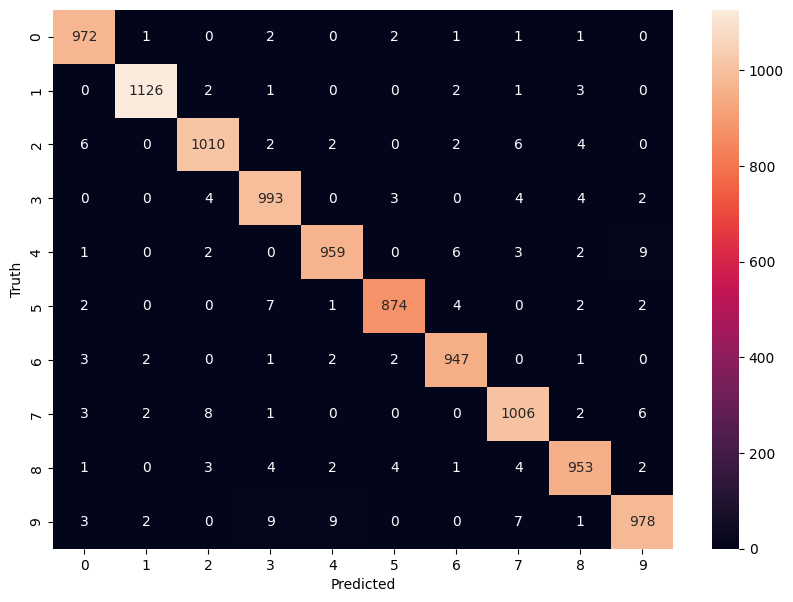

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm=confusion_matrix(y_test,y_pred_final)

plt.figure(figsize=(10,7))
sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show()

#### ***Misclassified images***

In [22]:
index = 0
misclassified_images = []
for label, predict in zip(y_test, y_pred_final):
    if label != predict: 
        misclassified_images.append(index)
    index +=1
print(misclassified_images)
print(len(misclassified_images))

[151, 247, 321, 340, 445, 495, 582, 619, 646, 691, 720, 740, 951, 1003, 1014, 1039, 1112, 1128, 1156, 1182, 1226, 1232, 1242, 1247, 1253, 1319, 1328, 1395, 1414, 1494, 1522, 1530, 1549, 1553, 1609, 1670, 1678, 1681, 1754, 1790, 1901, 1941, 2024, 2043, 2070, 2098, 2109, 2118, 2125, 2130, 2135, 2182, 2185, 2291, 2293, 2298, 2369, 2387, 2405, 2488, 2582, 2607, 2635, 2648, 2654, 2771, 2810, 2877, 2921, 2939, 2953, 3060, 3073, 3117, 3225, 3490, 3503, 3520, 3549, 3558, 3567, 3597, 3604, 3718, 3780, 3808, 3850, 3853, 3869, 3906, 3926, 3941, 3943, 3985, 4065, 4078, 4123, 4140, 4163, 4176, 4199, 4201, 4224, 4248, 4289, 4360, 4369, 4497, 4508, 4536, 4548, 4567, 4723, 4731, 4807, 4823, 4874, 4876, 4879, 4880, 4956, 4966, 5067, 5331, 5409, 5457, 5642, 5676, 5734, 5887, 5936, 5937, 5955, 5973, 6011, 6035, 6059, 6071, 6091, 6166, 6555, 6560, 6571, 6576, 6597, 6625, 6641, 6651, 6755, 6783, 6847, 7216, 7434, 7481, 8094, 8277, 8325, 8520, 9009, 9015, 9019, 9024, 9280, 9587, 9634, 9664, 9669, 9679, 9692

#### ***Predicting the output***

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Was predicted  0
Was labeled  6
Predicted Probabilities:  [[9.9484837e-01 8.6202472e-06 5.1228568e-07 9.5007913e-08 1.5709349e-09
  3.5209891e-03 1.0854205e-03 5.3135061e-04 4.5769516e-06 1.1572285e-09]]


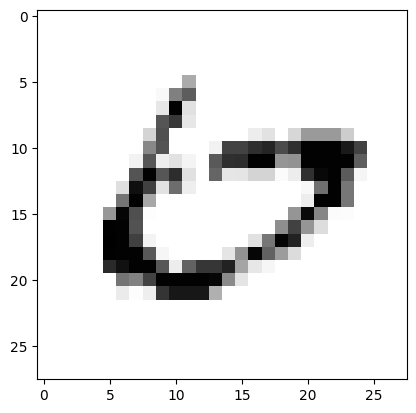

In [23]:
image_index = 445
plt.imshow(x_test[image_index].reshape(28, 28),cmap='Greys')
pred = model.predict(x_test[image_index].reshape(-1, 784))
print("Was predicted ",pred.argmax())
print("Was labeled ",y_test[image_index])
print("Predicted Probabilities: ",pred)

#### ***Accuracy curve***

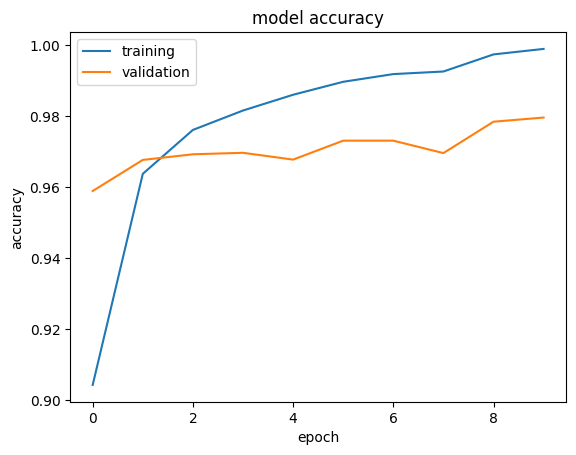

In [24]:
loss, accuracy  = model.evaluate(x_test, y_test_cat, verbose=False)
    
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['training', 'validation'], loc='best')
plt.show()